In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving transactions.csv to transactions.csv


In [ ]:
#load data csv
df = pd.read_csv('transactions.csv', sep=';')
display(df.head())

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch
0,733493772,733493772,5000,5000,2016-01-08T19:04:50,111.33.00,Lyft,US,US,5.0,...,03/08/14,03/08/14,492,492,9184,PURCHASE,True,0,False,False
1,733493772,733493772,5000,4888.67,2016-01-09T22:32:39,24.75,Uber,US,US,9.0,...,03/08/14,03/08/14,492,492,9184,PURCHASE,False,111.33.00,False,False
2,733493772,733493772,5000,4863.92,2016-01-11T13:36:55,187.04.00,Lyft,US,US,5.0,...,03/08/14,03/08/14,492,492,9184,PURCHASE,False,136.08.00,False,False
3,733493772,733493772,5000,4676.52.00,2016-01-11T22:47:46,227.34.00,Lyft,US,US,2.0,...,03/08/14,03/08/14,492,492,9184,PURCHASE,True,323.48.00,False,False
4,733493772,733493772,5000,4449.18.00,2016-01-16T01:41:11,0,Lyft,US,US,2.0,...,03/08/14,03/08/14,492,492,9184,ADDRESS_VERIFICATION,False,550.82,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641914 entries, 0 to 641913
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             641914 non-null  int64  
 1   customerId                641914 non-null  int64  
 2   creditLimit               641914 non-null  int64  
 3   availableMoney            641914 non-null  object 
 4   transactionDateTime       641914 non-null  object 
 5   transactionAmount         641914 non-null  object 
 6   merchantName              641914 non-null  object 
 7   acqCountry                638001 non-null  object 
 8   merchantCountryCode       641290 non-null  object 
 9   posEntryMode              638569 non-null  float64
 10  posConditionCode          641627 non-null  float64
 11  merchantCategoryCode      641914 non-null  object 
 12  currentExpDate            641914 non-null  object 
 13  accountOpenDate           641914 non-null  o

In [ ]:
df.describe()

,accountNumber,customerId,creditLimit,posEntryMode,posConditionCode,cardCVV,enteredCVV,cardLast4Digits
count,6.419140e+05,6.419140e+05,641914.000000,638569.000000,641627.000000,641914.000000,641914.000000,641914.000000
mean,5.547701e+08,5.547701e+08,10697.210608,9.136460,3.238367,557.199927,556.775160,4886.184043
std,2.546884e+08,2.546884e+08,11460.359133,16.961185,9.680862,257.326204,257.402639,2859.053679
min,1.005471e+08,1.005471e+08,250.000000,2.000000,1.000000,100.000000,1.000000,0.000000
25%,3.223192e+08,3.223192e+08,5000.000000,2.000000,1.000000,334.000000,333.000000,2364.000000
50%,5.438879e+08,5.438879e+08,7500.000000,5.000000,1.000000,581.000000,580.000000,4873.000000
75%,7.862277e+08,7.862277e+08,15000.000000,9.000000,1.000000,762.000000,761.000000,7267.000000
max,9.999853e+08,9.999853e+08,50000.000000,90.000000,99.000000,998.000000,998.000000,9998.000000


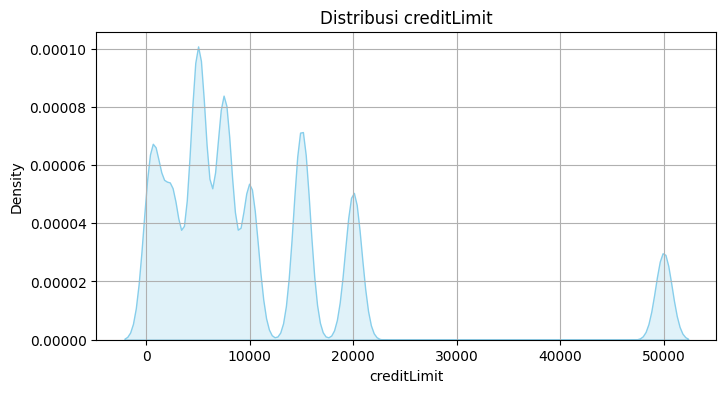

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='creditLimit', fill=True, color='skyblue')
plt.title('Distribusi creditLimit')
plt.xlabel('creditLimit')
plt.ylabel('Density')
plt.grid()
plt.show()

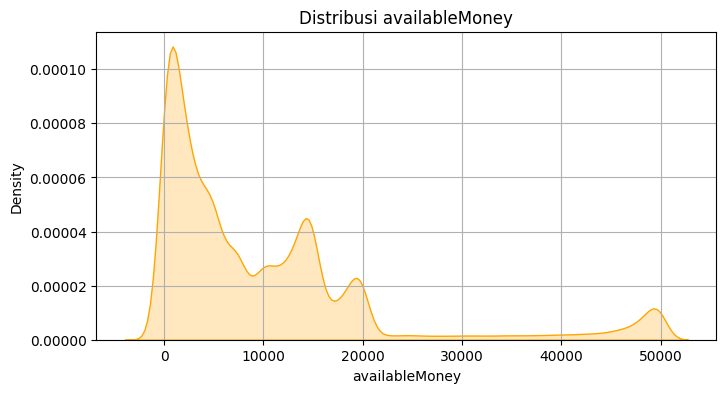

In [ ]:
df['availableMoney'] = pd.to_numeric(df['availableMoney'], errors='coerce')

plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='availableMoney', fill=True, color='orange')
plt.title('Distribusi availableMoney')
plt.xlabel('availableMoney')
plt.ylabel('Density')
plt.grid()
plt.show()

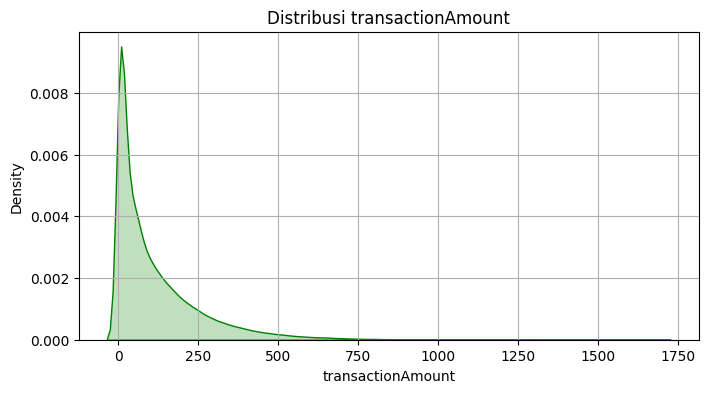

In [ ]:
df['transactionAmount'] = pd.to_numeric(df['transactionAmount'], errors='coerce')

df = df.dropna(subset=['transactionAmount'])

plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='transactionAmount', fill=True, color='green')
plt.title('Distribusi transactionAmount')
plt.xlabel('transactionAmount')
plt.ylabel('Density')
plt.grid()
plt.show()

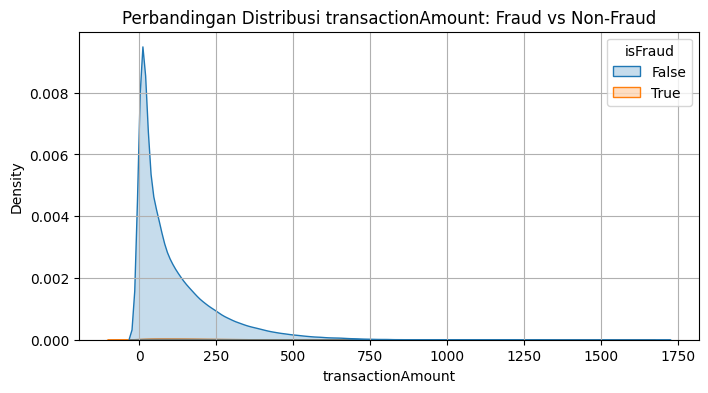

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='transactionAmount', hue='isFraud', fill=True)
plt.title('Perbandingan Distribusi transactionAmount: Fraud vs Non-Fraud')
plt.xlabel('transactionAmount')
plt.ylabel('Density')
plt.grid()
plt.show()

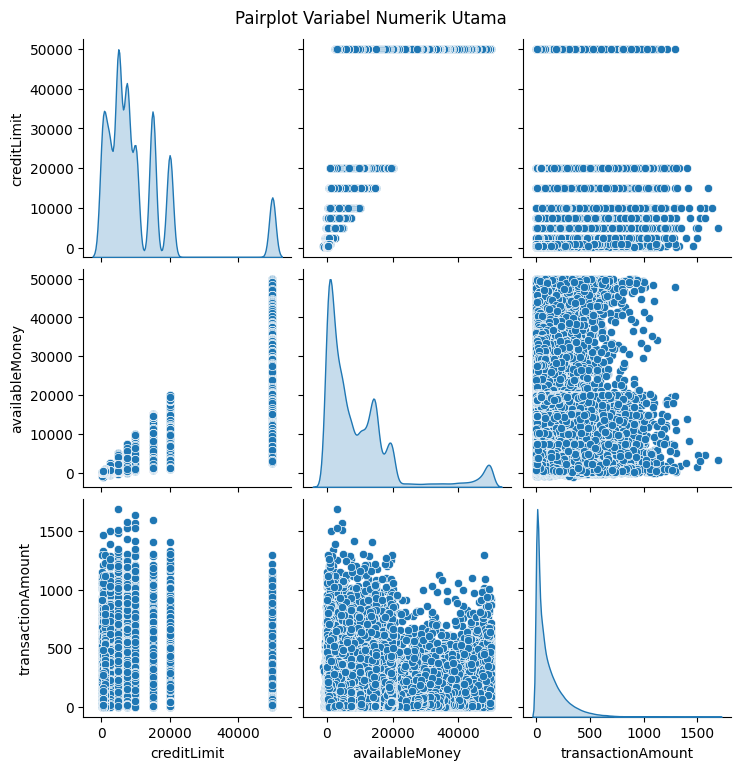

In [ ]:
#bifariat test
num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']

sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle('Pairplot Variabel Numerik Utama', y=1.02)
plt.show()

In [ ]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

/tmp/ipython-input-4194774425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


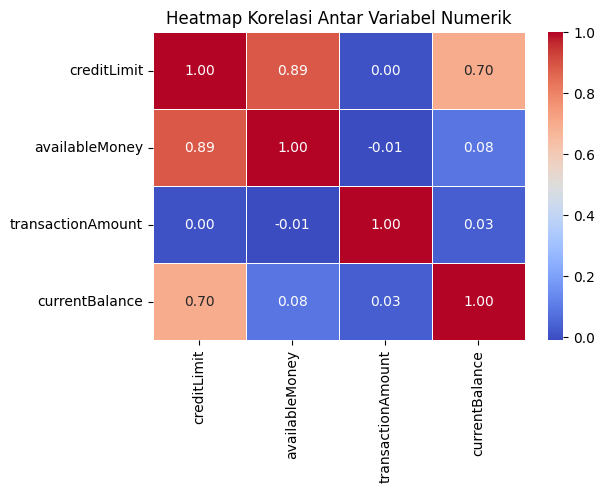

In [ ]:
num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']
corr = df[num_cols].corr()

# Visualisasikan dengan heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

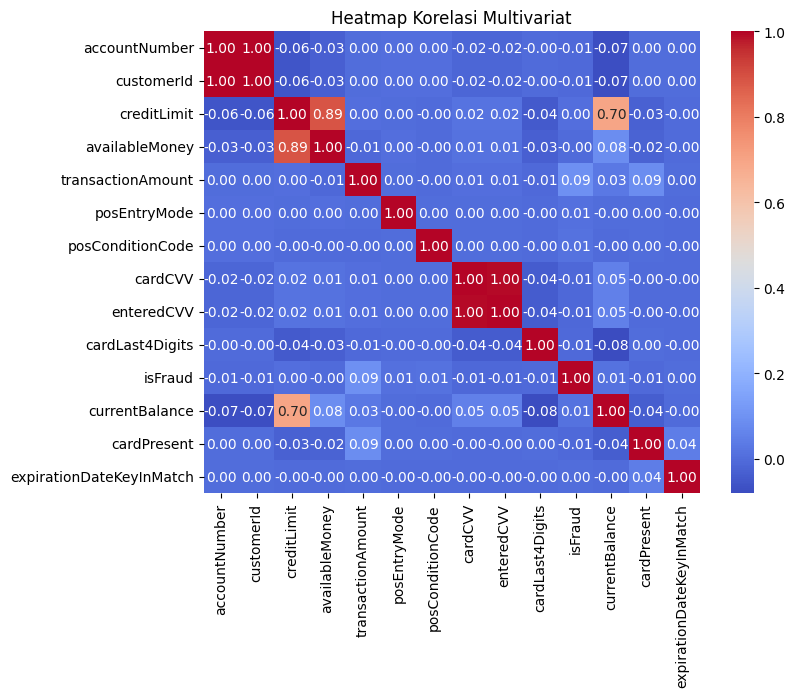

In [ ]:
#multivariat testing
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Multivariat')
plt.show()

In [ ]:
#copy data
df_clean = df.copy(deep=True)

In [ ]:
#mencari data null
df_clean.isnull().sum()

,0
accountNumber,0
customerId,0
creditLimit,0
availableMoney,133396
transactionDateTime,0
transactionAmount,0
merchantName,0
acqCountry,1705
merchantCountryCode,294
posEntryMode,1410


In [ ]:
#menghapus semua baris yg null
df.dropna(how='any', inplace=True)

In [ ]:
df.dropna(how='any', inplace=True)
df

/tmp/ipython-input-1598537464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(how='any', inplace=True)


,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch
26,733493772,733493772,5000,3232.00,2016-03-04T04:42:44,105.66,Fresh Online Services,US,US,9.0,...,03/08/14,03/08/14,492,492,9184,PURCHASE,False,1768.00,False,False
176,578754168,578754168,5000,5000.00,2016-02-23T08:46:36,17.54,Regal Cinemas #729464,US,US,2.0,...,21/10/15,21/10/15,413,413,5279,PURCHASE,False,0.00,True,False
177,578754168,578754168,5000,5000.00,2016-03-02T00:00:34,122.96,EZ Putt Putt #240241,US,US,5.0,...,21/10/15,21/10/15,413,413,5279,PURCHASE,False,0.00,True,False
184,578754168,578754168,5000,5000.00,2016-04-14T05:25:15,26.79,Shell Gas #69785,US,US,5.0,...,21/10/15,21/10/15,413,413,5279,PURCHASE,False,0.00,True,False
186,578754168,578754168,5000,5000.00,2016-05-12T13:02:40,23.33,Shell Gas #69785,US,US,5.0,...,21/10/15,21/10/15,413,413,5279,PURCHASE,False,0.00,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641848,455115932,455115932,50000,27757.92,2016-12-13T10:14:38,44.94,Shell Gas #988905,US,US,5.0,...,02/02/11,02/02/11,148,148,2521,PURCHASE,False,22242.08,True,False
641849,455115932,455115932,50000,27712.98,2016-12-14T13:21:21,21.26,netflix.com,US,US,5.0,...,02/02/11,02/02/11,148,148,2521,PURCHASE,False,22287.02,False,False
641854,455115932,455115932,50000,27485.89,2016-12-30T10:38:16,11.21,Blue Mountain eCards,US,US,5.0,...,02/02/11,02/02/11,148,148,2521,PURCHASE,False,22514.11,False,False
641858,808328364,808328364,7500,7500.00,2016-08-28T11:57:28,123.65,alibaba.com,US,US,5.0,...,04/06/07,04/06/07,732,732,965,PURCHASE,False,0.00,False,False


In [ ]:
df_clean.isnull().sum()

,0
accountNumber,0
customerId,0
creditLimit,0
availableMoney,133396
transactionDateTime,0
transactionAmount,0
merchantName,0
acqCountry,1705
merchantCountryCode,294
posEntryMode,1410


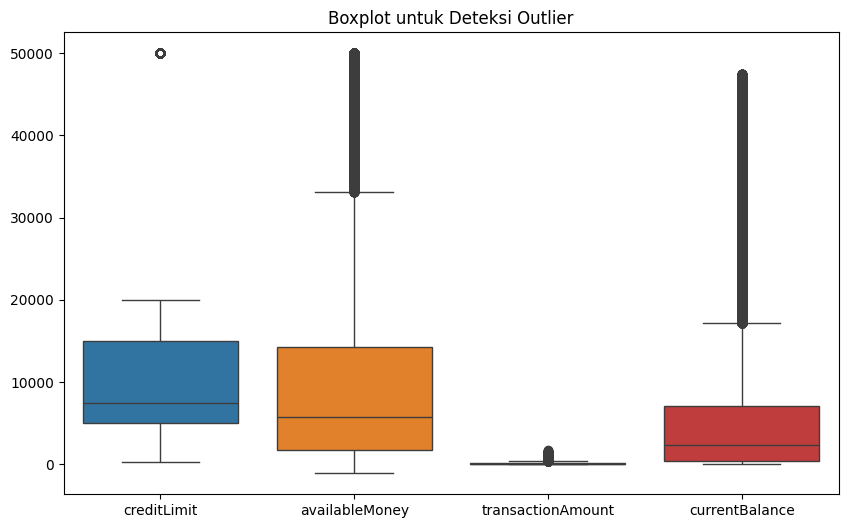

In [ ]:
#mencoba deteksi outliar dengan cara pairplot
num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean[num_cols])
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()

In [ ]:
import numpy as np

for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

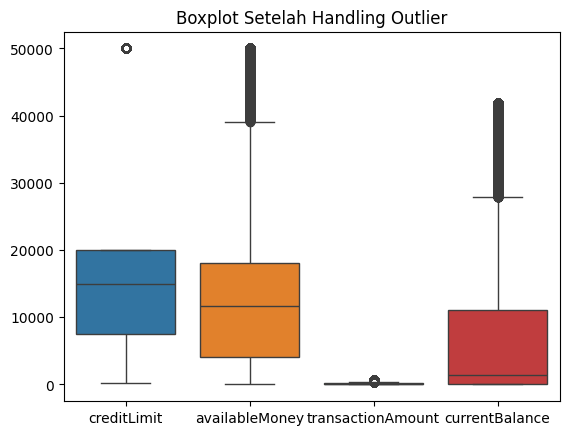

In [ ]:
sns.boxplot(data=df[num_cols])
plt.title("Boxplot Setelah Handling Outlier")
plt.show()


In [ ]:
df_no_outlier = df_clean.copy()

num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']
X = df_no_outlier[num_cols].copy()



In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']

# Ambil data bersih dari dataframe yang kamu punya (ganti df_clean/df sesuai datasetmu)
df_no_outlier = df_clean.copy()

# Konversi ke numerik (paksa ubah string jadi angka)
for col in num_cols:
    df_no_outlier[col] = pd.to_numeric(df_no_outlier[col], errors='coerce')

# Hapus baris yang mengandung nilai NaN
df_no_outlier = df_no_outlier.dropna(subset=num_cols)

# Ambil subset numerik
X = df_no_outlier[num_cols]
print("Cek jumlah NaN:", X.isnull().sum())


Cek jumlah NaN: creditLimit          0
availableMoney       0
transactionAmount    0
currentBalance       0
dtype: int64


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print("Bentuk data setelah scaling:", X_scaled.shape)


Bentuk data setelah scaling: (49457, 4)


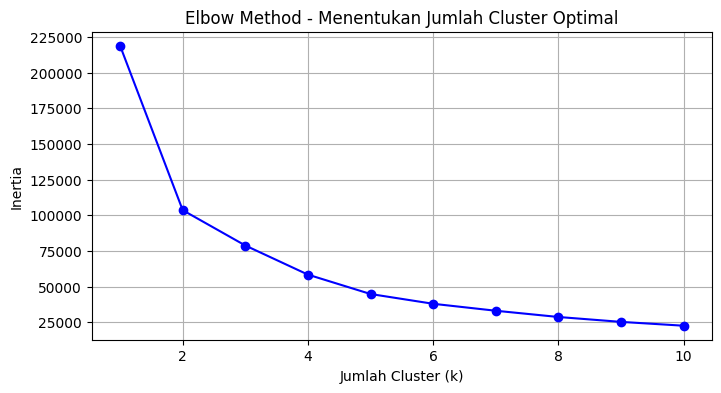

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Menentukan Jumlah Cluster Optimal')
plt.grid()
plt.show()



In [ ]:
from sklearn.cluster import KMeans

k_choice = 6
kmeans = KMeans(n_clusters=k_choice, random_state=42, n_init=50)
kmeans.fit(X_scaled)

df_no_outlier['cluster'] = kmeans.labels_

print(df_no_outlier['cluster'].value_counts())


cluster
5    15363
0    11882
3     6529
4     5628
1     5092
2     4963
Name: count, dtype: int64


In [ ]:
num_cols = ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']

cluster_summary = df_no_outlier.groupby('cluster')[num_cols].mean().round(2)
print(cluster_summary)


         creditLimit  availableMoney  transactionAmount  currentBalance
cluster                                                                
0            3117.05         2808.62              65.93          308.43
1           50000.00        19074.93             124.57        30925.07
2           12940.06         9250.48             414.13         3689.58
3           17740.08         4892.45              79.45        12847.64
4           50000.00        43122.38             108.61         6877.62
5           16540.71        14886.54              64.33         1654.17


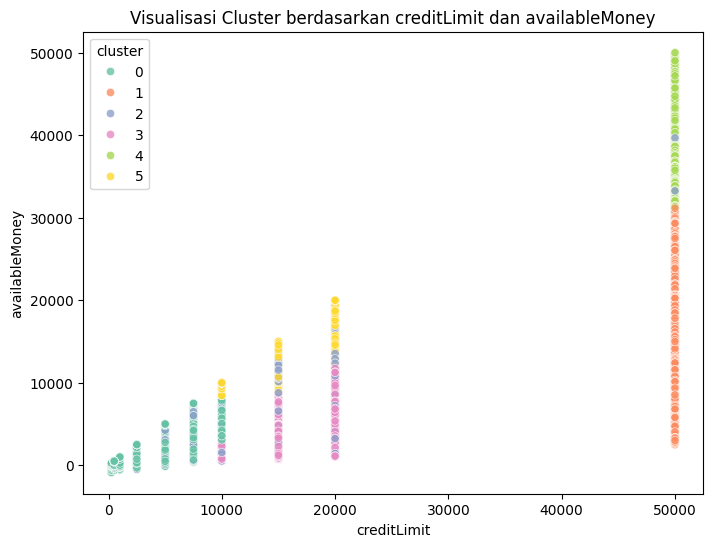

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_no_outlier, x='creditLimit', y='availableMoney', hue='cluster', palette='Set2', alpha=0.8)
plt.title('Visualisasi Cluster berdasarkan creditLimit dan availableMoney')
plt.show()


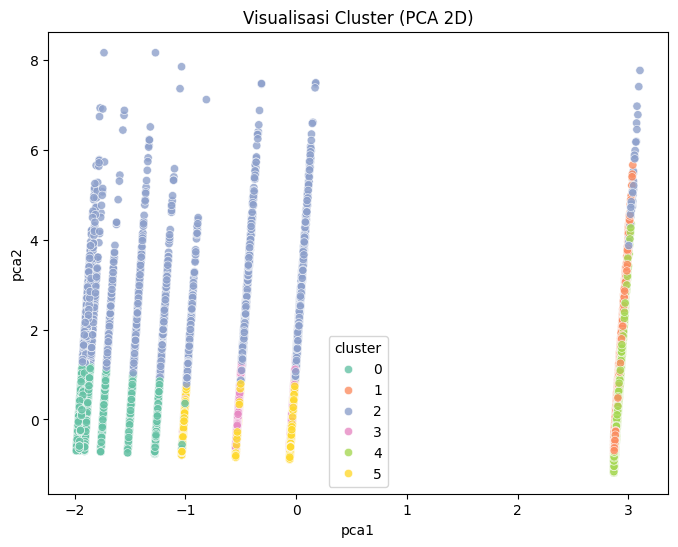

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
df_no_outlier['pca1'] = pca_result[:,0]
df_no_outlier['pca2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_no_outlier, x='pca1', y='pca2', hue='cluster', palette='Set2', alpha=0.8)
plt.title('Visualisasi Cluster (PCA 2D)')
plt.show()
